# 02 - Construccion de Features 

Proposito: construir los features de lluvia acumulada e intantanea para poder tratar el problema como un forecasting de eventos aislados y no un problema de series temporales dependiente de una linea de tiempo.

Con el fin de examinar el efecto de la precipitación sobre los picos de nivel del arroyo, se derivaron dos tipos de características a partir de los datos meteorológicos: la precipitación instantánea $R(t)$ y la precipitación acumulada $R_i^{acc}$. Las acumulaciones se determinaron utilizando ventanas deslizantes de distinta longitud, que cubren el período comprendido entre los 80 minutos previos al evento pico (denotado como $t_8$) y un horizonte de predicción específico $t_i = t_0 - H$, donde $H$ representa el número de minutos anteriores a la marca de tiempo de referencia $t_0$. 
Cada ventana de acumulación se define como:

\begin{equation}
    R_i^{acc} = \sum_{t = t_8}^{t_0 - H - i} R(t),
\end{equation}

donde $R(t)$ representa la intensidad de precipitación en el instante $t$, y la sumatoria abarca la ventana temporal correspondiente que finaliza en el horizonte de predicción.

Esta formulación permite que los modelos integren tanto las intensidades recientes de precipitación (a través de $R(t)$) como los patrones temporales más amplios (a través de $R_i^{acc}$). Las características derivadas sirven como variables de entrada para los modelos de regresión y clasificación, con el propósito de reflejar las dinámicas temporales de la respuesta hidrológica del arroyo.

Esta formulación permite que los modelos integren tanto las intensidades recientes de precipitación (a través de $R(t)$) como los patrones temporales más amplios (a través de $R_i^{acc}$). Las características derivadas sirven como variables de entrada para los modelos de regresión y clasificación, con el propósito de reflejar las dinámicas temporales de la respuesta hidrológica del arroyo.

## Construccion de Features: Rain instantanea y Rain acumulada
Instantáneos: R(t4), R(t6) → lluvia en los 10 min que terminan 40 y 60 min antes del pico.

Acumulados: Racc_t6(L=60), Racc_t7(L=70) → lluvia acumulada en 60 y 70 min que terminan 60 y 70 min antes del pico.


1. Usa la función find_peaks() de SciPy para detectar los máximos locales (picos). 
    - distance=3 → obliga a que haya al menos 3 intervalos de 10 min (≈30 min) entre picos, evitando que se detecten varios picos muy cercanos.

    - prominence=0.05 → controla qué tan “relevante” o alto debe ser un pico respecto a su entorno para considerarse significativo. Cuanto mayor sea, menos picos detectará (filtra los pequeños aumentos de nivel).

    Resultado: peaks_idx contiene las posiciones (índices numéricos) de los picos detectados, y props guarda propiedades de cada pico (altura, prominencia, ancho, etc.).

2. Convierte esas posiciones en marcas de tiempo reales (timestamps). Así obtenés la lista de momentos en que el nivel alcanzó un máximo relevante.
3. Imprime cuántos picos se detectaron y muestra los primeros 5 para verificar visualmente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Se cargan los datos del SIL
df = pd.read_csv(r'G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\processed\datos_lluvia_nivel\Mburicao_2021-2025_mean_cero.csv', parse_dates=["Time"])
df= df.set_index("Time").sort_index()
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 85804 entries, 2021-06-12 12:00:00 to 2026-03-17 09:30:00
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nivel          85804 non-null  float64
 1   Precipitacion  85804 non-null  float64
dtypes: float64(2)
memory usage: 2.0 MB


In [3]:
df.index

DatetimeIndex(['2021-06-12 12:00:00', '2021-06-12 12:10:00',
               '2021-06-12 12:20:00', '2021-06-12 12:30:00',
               '2021-06-12 12:40:00', '2021-06-12 12:50:00',
               '2021-06-12 13:00:00', '2021-06-12 13:10:00',
               '2021-06-12 13:20:00', '2021-06-12 13:30:00',
               ...
               '2026-03-17 08:35:00', '2026-03-17 08:40:00',
               '2026-03-17 08:45:00', '2026-03-17 08:50:00',
               '2026-03-17 08:55:00', '2026-03-17 09:00:00',
               '2026-03-17 09:05:00', '2026-03-17 09:20:00',
               '2026-03-17 09:25:00', '2026-03-17 09:30:00'],
              dtype='datetime64[us]', name='Time', length=85804, freq=None)

In [4]:
# prueba para ver cuanto deberia de ser el parametro de prominence en el find_peaks, se puede usar el metodo describe para ver los percentiles y asi elegir un valor adecuado
#En find_peaks, el parámetro prominence mide qué tan “destacado” es un pico respecto a su entorno.
#si el prominence = 0.05 a idea no es que el pico tenga altura absoluta mayor a 0.05, sino que tenga una diferencia vertical mínima respecto a la base cercana.
from scipy.signal import find_peaks
import pandas as pd

peaks_idx, props = find_peaks(
    df["Nivel"].values,
    distance=3,
    prominence=0.01
)

prominencias = pd.Series(
    props["prominences"],
    index=df.index[peaks_idx],
    name="prominence"
)

prominencias.describe()

count    1704.000000
mean        0.084384
std         0.288572
min         0.010000
25%         0.010000
50%         0.030000
75%         0.040000
max         3.715737
Name: prominence, dtype: float64

In [5]:
prominencias.sort_values(ascending=False).head(20)

Time
2022-03-23 10:00:00    3.715737
2022-03-22 18:50:00    3.523000
2026-03-16 19:35:00    2.720000
2026-03-16 16:00:00    2.720000
2026-01-28 16:50:00    2.540000
2022-03-10 22:00:00    2.474960
2022-02-04 18:00:00    2.371487
2021-10-13 20:40:00    2.226633
2026-03-03 16:15:00    2.170000
2025-09-30 09:05:00    2.090000
2026-01-01 21:30:00    2.020000
2026-02-13 11:05:00    1.990000
2026-02-02 18:25:00    1.930000
2025-11-16 16:35:00    1.790000
2026-02-24 17:45:00    1.780000
2021-11-25 15:20:00    1.714245
2026-03-08 18:50:00    1.660000
2025-10-28 12:40:00    1.580000
2025-11-12 13:10:00    1.490000
2022-03-18 17:50:00    1.456000
Name: prominence, dtype: float64

<Axes: >

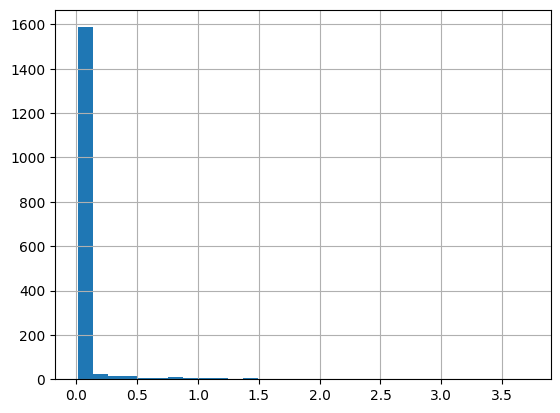

In [6]:
prominencias.hist(bins=30)

Elijamos un prominence de 10cm por ahora.
Cuando lo pongo en 0.05 en el dataset quedan muchos eventos de picos en los cuales todos sus features de entrada son cero, entonces esto hace que el modelo no sepa predecir estos picos que no tienen features de entrada y da malas metricas. 

In [7]:
# aqui podemos ver el distance entre los picos, que es el tiempo entre eventos, y asi elegir un valor adecuado para el distance
dt = df.index.to_series().diff().median()
dt

#si elegimos un distance de 3, eso significa que queremos que los picos esten separados por al menos 3*dt, es decir, 
# 3*5min = 15min, para los datos del 2025 y 3*10min = 30min para los datos del 2021.

Timedelta('0 days 00:05:00')

- Prominence controla qué tan importante es el pico en altura. 
- Distance controla qué tan separados deben estar los picos en el tiempo.

In [8]:
from scipy.signal import find_peaks
#Picos del dataset de nivel sin suavizado (original)
#1.
peaks_idx, props = find_peaks(df["Nivel"].values, distance=3, prominence=0.5) # cuanto deberia de ser el prominence ?
#2.
peaks_ts = df.index[peaks_idx]
#3.
len(peaks_ts), peaks_ts[:5]

(67,
 DatetimeIndex(['2021-07-15 05:10:00', '2021-09-08 10:20:00',
                '2021-09-13 23:10:00', '2021-10-01 02:50:00',
                '2021-10-01 23:50:00'],
               dtype='datetime64[us]', name='Time', freq=None))

In [9]:
# Se definen funciones utilitarias para crear las preciptaciones acumuladas e instantaneas
STEP = pd.Timedelta(minutes=10)  # resolución base

def R_ti(series_rain, t0, i):
    """
    R(t_i): lluvia en el intervalo de 10 min que TERMINA i*10 min antes de t0.
    """
    end = t0 - i*STEP
    start = end - STEP
    # Suma en esa ventana exacta (siempre 10 min), en este caso, como el sample rate es 10min y ya lo normalizamos a eso antes, no haria falta el .sum()
    return series_rain.loc[start:end].sum()

def Racc_ti(series_rain, t0, i, L_minutes):
    """
    Racc_ti(L): lluvia acumulada en L minutos que TERMINAN i*10 min antes de t0.
    """
    end = t0 - i*STEP
    start = end - pd.Timedelta(minutes=L_minutes)
    return series_rain.loc[start:end].sum()


In [10]:
rows = []
for t0 in peaks_ts:
    # Asegurarnos de tener historia suficiente (hasta 80–90 min antes del pico)
    if t0 - pd.Timedelta(minutes=90) < df.index.min():
        continue

    y_peak = df.at[t0, "Nivel"]  # target: nivel en el pico

    # features (config H=4 es decir horizonte de 40 min)
    #features de lluvia instantanea
    f_R_t1 = R_ti(df["Precipitacion"], t0, 1)             # 10 min antes
    f_R_t2 = R_ti(df["Precipitacion"], t0, 2)             # 20 min antes
    f_R_t3 = R_ti(df["Precipitacion"], t0, 3)             # 30 min antes
    f_R_t4 = R_ti(df["Precipitacion"], t0, 4)             # 40 min antes
    f_R_t5 = R_ti(df["Precipitacion"], t0, 5)             # 50 min antes
    f_R_t6 = R_ti(df["Precipitacion"], t0, 6)             # 60 min antes
    f_R_t7 = R_ti(df["Precipitacion"], t0, 7)             # 70 min antes
    f_R_t8 = R_ti(df["Precipitacion"], t0, 8)             # 80 min antes

    #features de lluvia acumulada
    f_Racc_t6_L10 = Racc_ti(df["Precipitacion"], t0, 1, 10)
    f_Racc_t6_L20 = Racc_ti(df["Precipitacion"], t0, 2, 20)
    f_Racc_t6_L30 = Racc_ti(df["Precipitacion"], t0, 3, 30)
    f_Racc_t6_L40 = Racc_ti(df["Precipitacion"], t0, 4, 40)
    f_Racc_t6_L50 = Racc_ti(df["Precipitacion"], t0, 5, 50)
    f_Racc_t6_L60 = Racc_ti(df["Precipitacion"], t0, 6, 60)
    f_Racc_t7_L70 = Racc_ti(df["Precipitacion"], t0, 7, 70)
    f_Racc_t6_L80 = Racc_ti(df["Precipitacion"], t0, 8, 80)

    rows.append({
        "t0": t0,
        "y_peak_m": y_peak,
        "R_t1": f_R_t1,
        "R_t2": f_R_t2,
        "R_t3": f_R_t3,
        "R_t4": f_R_t4,
        "R_t5": f_R_t5,
        "R_t6": f_R_t6,
        "R_t7": f_R_t7,
        "R_t8": f_R_t8,

        "Racc_t1_L10": f_Racc_t6_L10,
        "Racc_t2_L20": f_Racc_t6_L20,
        "Racc_t3_L30": f_Racc_t6_L30,
        "Racc_t4_L40": f_Racc_t6_L40,
        "Racc_t5_L50": f_Racc_t6_L50, 
        "Racc_t6_L60": f_Racc_t6_L60,
        "Racc_t7_L70": f_Racc_t7_L70,
        "Racc_t8_L80": f_Racc_t6_L80,
    })

Xy_events = pd.DataFrame(rows).dropna().reset_index(drop=True)
Xy_events.head(), Xy_events.shape


(                   t0  y_peak_m  R_t1  R_t2  R_t3  R_t4  R_t5  R_t6  R_t7  \
 0 2021-07-15 05:10:00  1.254661   2.4   1.2   3.6   7.6   9.2   5.4   0.8   
 1 2021-09-08 10:20:00  0.694439   1.2   0.4   1.0   1.4   1.6   1.6   1.2   
 2 2021-09-13 23:10:00  0.838219   1.6   0.2   0.0   0.0   0.2   6.2   6.4   
 3 2021-10-01 02:50:00  1.130979   1.0   0.4   0.0   1.2   4.8   3.6   0.0   
 4 2021-10-01 23:50:00  0.620044   0.2   0.2   0.0   0.2   0.4   0.8   2.0   
 
    R_t8  Racc_t1_L10  Racc_t2_L20  Racc_t3_L30  Racc_t4_L40  Racc_t5_L50  \
 0   0.4          2.4          4.2         12.8         13.0         10.8   
 1   2.4          1.2          1.2          2.6          3.6          5.8   
 2   0.4          1.6          0.2          0.2          6.6          6.6   
 3   0.0          1.0          0.4          4.8          4.8          4.8   
 4   2.2          0.2          0.2          0.4          2.4          3.2   
 
    Racc_t6_L60  Racc_t7_L70  Racc_t8_L80  
 0          7.4       

In [11]:
Xy_events.columns

Index(['t0', 'y_peak_m', 'R_t1', 'R_t2', 'R_t3', 'R_t4', 'R_t5', 'R_t6',
       'R_t7', 'R_t8', 'Racc_t1_L10', 'Racc_t2_L20', 'Racc_t3_L30',
       'Racc_t4_L40', 'Racc_t5_L50', 'Racc_t6_L60', 'Racc_t7_L70',
       'Racc_t8_L80'],
      dtype='str')

In [12]:
X = Xy_events[['R_t1', 'R_t2', 'R_t3', 'R_t4', 'R_t5', 'R_t6',
       'R_t7', 'R_t8', 'Racc_t1_L10', 'Racc_t2_L20', 'Racc_t3_L30',
       'Racc_t4_L40', 'Racc_t5_L50', 'Racc_t6_L60', 'Racc_t7_L70',
       'Racc_t8_L80']]
y = Xy_events["y_peak_m"]

# Estrategia de selección de Features: Mutual information 


Con el objetivo de identificar las variables meteorológicas más relevantes para la predicción del nivel del arroyo, se aplicó un criterio basado en la Información Mutua (Mutual Information, MI). Este enfoque permite cuantificar la dependencia estadística entre cada característica de entrada y la variable objetivo, capturando tanto relaciones lineales como no lineales. A diferencia de la correlación de Pearson, que mide únicamente la dependencia lineal, la MI evalúa cuánta información comparte una variable con otra, expresada en términos de entropía.

Para una variable aleatoria continua $X$ (por ejemplo, la precipitación acumulada) y una variable objetivo $Y$ (por ejemplo, el nivel del arroyo o su clase binaria), la información mutua se define como:

\begin{equation}
I(X; Y) = \int_{Y} \int_{X} p(x,y) \, \log \left( \frac{p(x,y)}{p(x)p(y)} \right) dx \, dy,
\end{equation}

donde $p(x,y)$ es la función de densidad conjunta de $X$ y $Y$, y $p(x)$ y $p(y)$ son sus densidades marginales. Valores altos de $I(X;Y)$ indican que la característica $X$ aporta información significativa para predecir $Y$.

En este estudio, la información mutua se calculó de manera diferenciada para los dos tipos de modelos desarrollados:

- Casos de regresión: se utilizó el estimador continuo de información mutua "mutual_info_regression" del paquete scikit-learn, adecuado para variables objetivo continuas como el nivel de agua del arroyo.
- Casos de clasificación: se empleó el estimador discreto "mutual_info_classification" del mismo paquete, apropiado para variables objetivo categóricas, en este caso un indicador binario que distingue si el nivel del arroyo supera o no un umbral crítico.
  


In [13]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)
print(mi_series)

Racc_t3_L30    0.522267
Racc_t2_L20    0.511086
R_t3           0.510419
Racc_t6_L60    0.353065
R_t4           0.316615
Racc_t1_L10    0.306918
R_t1           0.297298
R_t2           0.284655
Racc_t4_L40    0.256289
Racc_t7_L70    0.214143
R_t7           0.197472
Racc_t5_L50    0.161323
R_t5           0.145135
Racc_t8_L80    0.129602
R_t8           0.024577
R_t6           0.013171
dtype: float64


Text(0.5, 1.0, 'Información Mutua - Regresión')

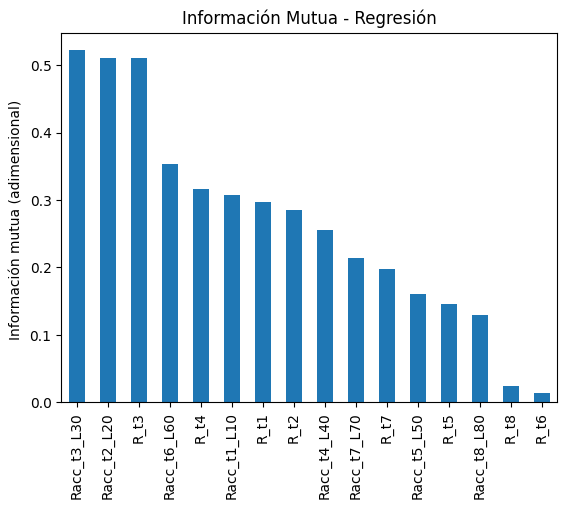

In [14]:
mi_series.plot(kind='bar')
#plt.xlabel("Características de precipitación")
plt.ylabel("Información mutua (adimensional) ")
plt.title("Información Mutua - Regresión")


In [56]:
#definimos los inputs y los outputs:
# tambien se incluye la feature t0 que es el timestamp del pico
#X = Xy_events[['t0','Racc_t6_L60','Racc_t5_L50', 'Racc_t4_L40', 'Racc_t3_L30', 'Racc_t2_L20', 'R_t3', 'R_t4']]
#X = Xy_events[['t0','Racc_t4_L40','Racc_t3_L30', 'Racc_t2_L20', 'R_t4', 'R_t3', 'R_t2']]
#X = Xy_events[['t0','Racc_t4_L40','Racc_t3_L30', 'Racc_t2_L20', 'R_t4', 'R_t3', 'R_t2']] #usado hasta el 18/05/2026
#X = Xy_events[['t0','Racc_t6_L60','Racc_t3_L30','Racc_t2_L20','Racc_t1_L10', 'R_t4', 'R_t3']] #creado el 19/05/2026, MI2

#todos los features de lluvia instantanea y acumulada, para ver como funciona asi el random forest
X = Xy_events[['t0','R_t1', 'R_t2', 'R_t3', 'R_t4', 'R_t5', 'R_t6',
       'R_t7', 'R_t8', 'Racc_t1_L10', 'Racc_t2_L20', 'Racc_t3_L30',
       'Racc_t4_L40', 'Racc_t5_L50', 'Racc_t6_L60', 'Racc_t7_L70',
       'Racc_t8_L80']]

Y = Xy_events["y_peak_m"]

In [57]:
X.head()

,t0,R_t1,R_t2,R_t3,R_t4,R_t5,R_t6,R_t7,R_t8,Racc_t1_L10,Racc_t2_L20,Racc_t3_L30,Racc_t4_L40,Racc_t5_L50,Racc_t6_L60,Racc_t7_L70,Racc_t8_L80
0,2021-07-15 05:10:00,2.4,1.2,3.6,7.6,9.2,5.4,0.8,0.4,2.4,4.2,12.8,13.0,10.8,7.4,7.4,16.2
1,2021-09-08 10:20:00,1.2,0.4,1.0,1.4,1.6,1.6,1.2,2.4,1.2,1.2,2.6,3.6,5.8,5.2,4.2,3.6
2,2021-09-13 23:10:00,1.6,0.2,0.0,0.0,0.2,6.2,6.4,0.4,1.6,0.2,0.2,6.6,6.6,6.6,6.4,1.2
3,2021-10-01 02:50:00,1.0,0.4,0.0,1.2,4.8,3.6,0.0,0.0,1.0,0.4,4.8,4.8,4.8,3.6,0.0,0.0
4,2021-10-01 23:50:00,0.2,0.2,0.0,0.2,0.4,0.8,2.0,2.2,0.2,0.2,0.4,2.4,3.2,3.0,2.8,2.2


In [58]:
Y.index

RangeIndex(start=0, stop=67, step=1)

In [59]:
#uno ambos en un mismo dataframe para tenerlos juntos, para mejor orden
df_features = X.join(Y, how="inner")
#df_features.set_index("t0", inplace=True)
df_features.head()

,t0,R_t1,R_t2,R_t3,R_t4,R_t5,R_t6,R_t7,R_t8,Racc_t1_L10,Racc_t2_L20,Racc_t3_L30,Racc_t4_L40,Racc_t5_L50,Racc_t6_L60,Racc_t7_L70,Racc_t8_L80,y_peak_m
0,2021-07-15 05:10:00,2.4,1.2,3.6,7.6,9.2,5.4,0.8,0.4,2.4,4.2,12.8,13.0,10.8,7.4,7.4,16.2,1.254661
1,2021-09-08 10:20:00,1.2,0.4,1.0,1.4,1.6,1.6,1.2,2.4,1.2,1.2,2.6,3.6,5.8,5.2,4.2,3.6,0.694439
2,2021-09-13 23:10:00,1.6,0.2,0.0,0.0,0.2,6.2,6.4,0.4,1.6,0.2,0.2,6.6,6.6,6.6,6.4,1.2,0.838219
3,2021-10-01 02:50:00,1.0,0.4,0.0,1.2,4.8,3.6,0.0,0.0,1.0,0.4,4.8,4.8,4.8,3.6,0.0,0.0,1.130979
4,2021-10-01 23:50:00,0.2,0.2,0.0,0.2,0.4,0.8,2.0,2.2,0.2,0.2,0.4,2.4,3.2,3.0,2.8,2.2,0.620044


Del 30 de octubre al 19 de noviembre del 2025 se deben de excluir eventos de pico ya que sensor de lluvia estuvo inactivo por lo tanto no tenemos los datos para armar los features de ese intervalo de tiempo


In [60]:
df_features["t0"] = pd.to_datetime(df_features["t0"])

inicio = "2025-10-30"
fin = "2025-11-19"

df_sin_intervalo = df_features[
    ~((df_features["t0"] >= inicio) & (df_features["t0"] <= fin))
].copy()

df_sin_intervalo

,t0,R_t1,R_t2,R_t3,R_t4,R_t5,R_t6,R_t7,R_t8,Racc_t1_L10,Racc_t2_L20,Racc_t3_L30,Racc_t4_L40,Racc_t5_L50,Racc_t6_L60,Racc_t7_L70,Racc_t8_L80,y_peak_m
0,2021-07-15 05:10:00,2.4,1.2,3.6,7.6,9.2,5.4,0.8,0.4,2.4,4.2,12.8,13.0,10.8,7.4,7.4,16.2,1.254661
1,2021-09-08 10:20:00,1.2,0.4,1.0,1.4,1.6,1.6,1.2,2.4,1.2,1.2,2.6,3.6,5.8,5.2,4.2,3.6,0.694439
2,2021-09-13 23:10:00,1.6,0.2,0.0,0.0,0.2,6.2,6.4,0.4,1.6,0.2,0.2,6.6,6.6,6.6,6.4,1.2,0.838219
3,2021-10-01 02:50:00,1.0,0.4,0.0,1.2,4.8,3.6,0.0,0.0,1.0,0.4,4.8,4.8,4.8,3.6,0.0,0.0,1.130979
4,2021-10-01 23:50:00,0.2,0.2,0.0,0.2,0.4,0.8,2.0,2.2,0.2,0.2,0.4,2.4,3.2,3.0,2.8,2.2,0.620044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2026-03-08 18:50:00,2.2,14.2,23.0,15.4,6.6,0.0,0.0,0.0,2.2,27.8,33.4,17.0,6.6,0.0,0.0,0.0,1.701707
63,2026-03-16 12:10:00,3.2,3.6,6.8,2.8,0.8,0.4,1.0,0.4,3.2,8.2,7.6,4.6,2.8,5.0,7.6,12.4,1.901707
64,2026-03-16 13:55:00,2.2,1.6,1.8,4.2,0.0,0.6,0.0,0.8,2.2,3.4,4.2,4.8,2.0,5.8,10.6,13.8,1.601707
65,2026-03-16 16:00:00,7.6,11.4,6.8,5.8,7.0,0.4,0.8,0.4,7.6,14.4,16.6,10.6,9.4,4.6,7.6,8.4,2.801707


In [61]:
df_sin_intervalo.to_csv(r"G:\Mi unidad\Maestria - IA\Tesis\Proyectos\Mburicao_Iberamia\data\processed\features_splits\mburicao_features_MI3_2021-2025_prominence_0.5_mean_cero.csv", index_label="Time")
